In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
df= pd.read_csv("../data/telco.csv")
pd.set_option("display.max_columns", None)

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Telco Customer Churn: Müşteri Kaybı Analizi 📋

## Proje Özeti ve Gerçek Hayat Problemi
İş dünyasında yeni bir müşteri kazanmanın maliyeti, mevcut bir müşteriyi elde tutma maliyetinden çok daha yüksektir. Telekomünikasyon sektöründe **"Churn"** (müşteri kaybı), bir müşterinin aboneliğini iptal etmesi anlamına gelir.

Bu projenin temel amacı, IBM tarafından paylaşılan örnek verileri kullanarak müşteri davranışlarını analiz etmek ve **"Hangi müşteriler bizi terk edebilir?"** sorusuna yanıt aramaktır. Bu sayede şirketler, henüz ayrılmamış ama ayrılma ihtimali yüksek olan müşterilere özel kampanyalar sunarak sadakati artırabilir.

---

## 🗂️ Veri Seti Yapısı
Veri seti, her biri bir müşteriyi temsil eden **7043 satır** ve müşteriye ait özellikleri içeren **21 sütundan** oluşmaktadır.

---

## 🎯 Hedef Değişken (Target)
- **Churn:** Müşterinin son bir ay içinde ayrılıp ayrılmadığı (`Yes/No`)

---

## 👤 Müşteri Demografisi

| Kolon İsmi      | Açıklama                             | Değer Aralığı          |
|-----------------|-------------------------------------|----------------------|
| gender          | Müşterinin cinsiyeti                 | Male, Female         |
| SeniorCitizen   | Müşterinin yaşlı olup olmadığı       | 1 (Evet), 0 (Hayır)  |
| Partner         | Müşterinin bir ortağı/eşi olup olmadığı | Yes, No           |
| Dependents      | Müşterinin bakmakla yükümlü olduğu kişiler olup olmadığı | Yes, No |

---

## 🛠️ Hizmet Bilgileri

| Kolon İsmi         | Açıklama                           | Seçenekler                        |
|-------------------|-----------------------------------|----------------------------------|
| tenure             | Müşterinin şirkette kaldığı ay sayısı | Sayısal                        |
| PhoneService       | Telefon hizmeti olup olmadığı      | Yes, No                          |
| MultipleLines      | Birden fazla hattı olup olmadığı   | Yes, No, No phone service        |
| InternetService    | İnternet servis sağlayıcısı       | DSL, Fiber optic, No             |
| OnlineSecurity     | Çevrimiçi güvenlik hizmeti         | Yes, No, No internet service    |
| OnlineBackup       | Çevrimiçi yedekleme hizmeti       | Yes, No, No internet service    |
| DeviceProtection   | Cihaz koruma hizmeti               | Yes, No, No internet service    |
| TechSupport        | Teknik destek hizmeti              | Yes, No, No internet service    |
| StreamingTV        | TV yayın hizmeti                   | Yes, No, No internet service    |
| StreamingMovies    | Film yayın hizmeti                 | Yes, No, No internet service    |

---

## 💳 Hesap ve Ödeme Bilgileri

| Kolon İsmi        | Açıklama                           | Seçenekler / Tip                 |
|------------------|-----------------------------------|---------------------------------|
| Contract          | Sözleşme süresi                    | Month-to-month, One year, Two year |
| PaperlessBilling  | Kağıtsız fatura tercihi            | Yes, No                         |
| PaymentMethod     | Ödeme yöntemi                       | Electronic check, Mailed check, Bank transfer, Credit card |
| MonthlyCharges    | Aylık tahsil edilen tutar           | Sayısal                          |
| TotalCharges      | Toplam tahsil edilen tutar          | Sayısal                          |

---

## 💡 Analiz Soruları (İlham Alınacak Noktalar)

- **Sözleşme Tipi:** Aylık sözleşme yapan müşteriler, yıllık yapanlara göre daha mı fazla churn ediyor?  
- **Hizmet Kalitesi:** Fiber optik kullanan müşterilerdeki memnuniyetsizlik oranı nedir?  
- **Sadakat (Tenure):** Yeni müşteriler ilk 6 ayda ayrılmaya daha mı meyilli?  
- **Ek Hizmetler:** Teknik destek veya online güvenlik gibi ek hizmet alanların sadakati daha mı yüksek?  

---

## 🔗 Kaynaklar
- **Veri Kaynağı:** [IBM Sample Data Sets](https://www.ibm.com/communities/analytics/watson-analytics-blog/guide-to-sample-datasets/)  
- **Güncel Versiyon:** IBM Community Blog


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.shape

(7043, 21)

In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Text(0.5, 1.0, 'Churn Oranı')

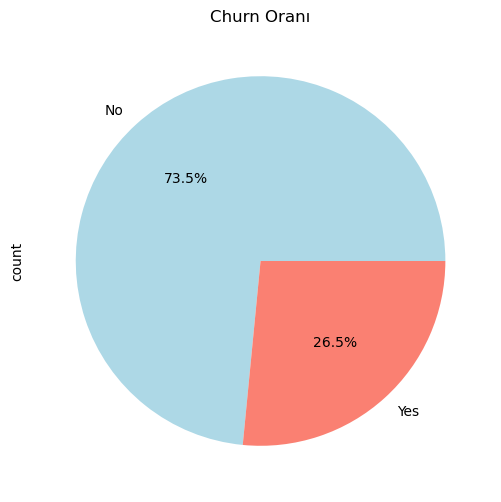

In [11]:
## churn edenlerin oranı daire grafiği
plt.figure(figsize=(6,6))
df["Churn"].value_counts().plot.pie(autopct="%1.1f%%", colors=["lightblue", "salmon"])
plt.title("Churn Oranı")

Text(0, 0.5, 'Sayı')

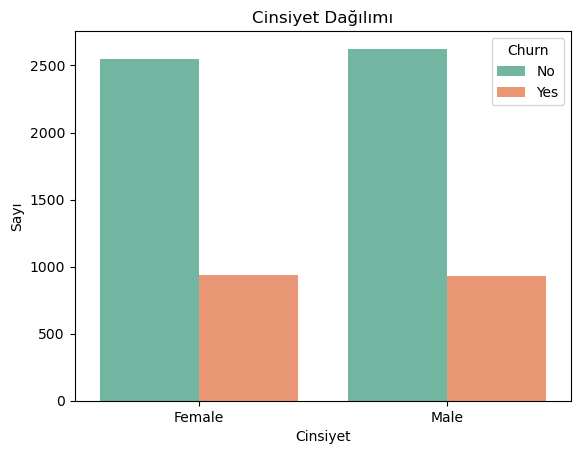

In [12]:
sns.countplot(data=df,x="gender",hue="Churn",palette="Set2")
plt.title("Cinsiyet Dağılımı")
plt.xlabel("Cinsiyet")
plt.ylabel("Sayı")

Text(0.5, 1.0, 'Aylık Ücret Dağılımı')

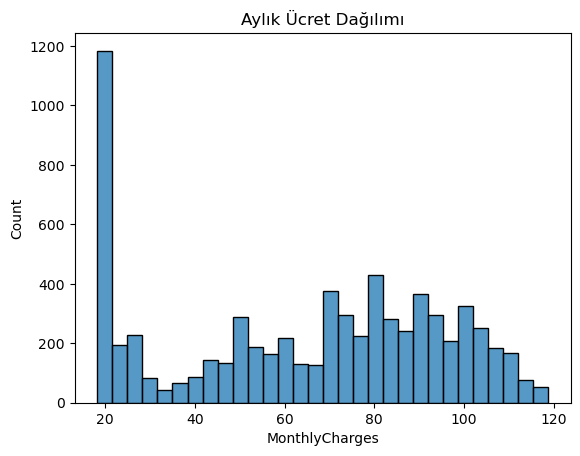

In [21]:
sns.histplot(df["MonthlyCharges"], bins=30)
plt.title("Aylık Ücret Dağılımı")

In [22]:
df.groupby("InternetService")["MonthlyCharges"].mean()

InternetService
DSL            58.102169
Fiber optic    91.500129
No             21.079194
Name: MonthlyCharges, dtype: float64

In [24]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


C:\Users\ahmet\AppData\Local\Temp\ipykernel_13248\558976770.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y="tenure", data=df, palette="Set3")


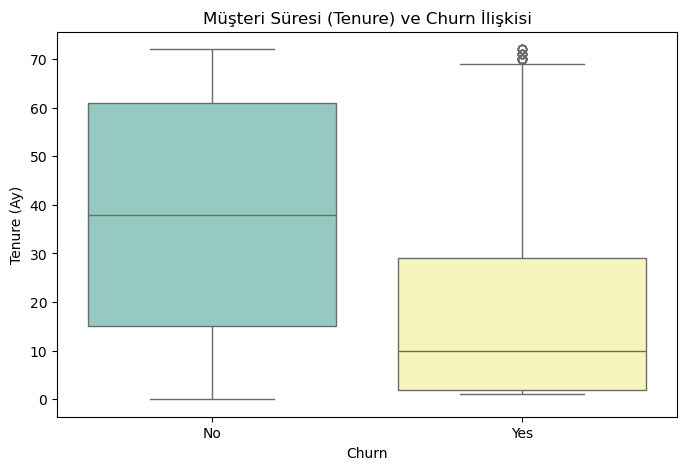

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="tenure", data=df, palette="Set3")

plt.title("Müşteri Süresi (Tenure) ve Churn İlişkisi")
plt.xlabel("Churn")
plt.ylabel("Tenure (Ay)")
plt.show()
# Tenure: müşterinin şirkette hizmet aldığı süreyi ay cinsinden gösterir.
# Grafiğe göre churn etmeyen müşterilerin tenure değerleri genel olarak daha yüksektir.
# Yani şirkette uzun süredir bulunan müşteriler hizmeti bırakma eğiliminde değildir.
# Churn eden müşterilerin tenure değerleri ise çoğunlukla düşüktür.
# Bu da yeni müşterilerin hizmetten daha hızlı ayrıldığını göstermektedir.
# Medyan değerlere bakıldığında churn etmeyen müşterilerin ortalama müşteri süresi
# churn eden müşterilere göre belirgin şekilde daha yüksektir.
# Bu sonuç müşteri bağlılığının zamanla arttığını ve özellikle ilk aylarda
# müşteri kaybının daha yüksek olduğunu göstermektedir.



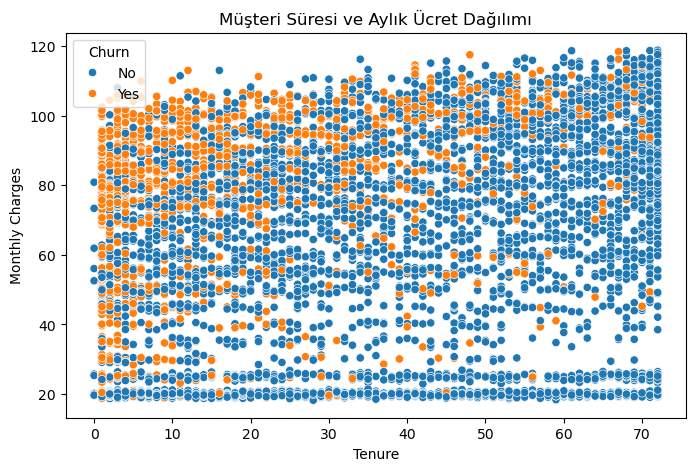

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    data=df
)

plt.title("Müşteri Süresi ve Aylık Ücret Dağılımı")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.show()

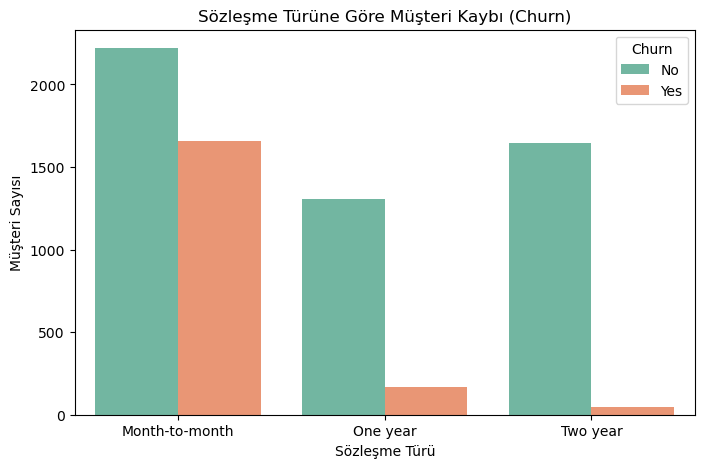

In [35]:
plt.figure(figsize=(8,5))
sns.countplot(
    x="Contract",
    hue="Churn",
    data=df,
    palette="Set2"
)
plt.title("Sözleşme Türüne Göre Müşteri Kaybı (Churn)")
plt.xlabel("Sözleşme Türü")
plt.ylabel("Müşteri Sayısı")
plt.show()


In [14]:
df["Partner"].value_counts()

Partner
No     3641
Yes    3402
Name: count, dtype: int64

In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
## 0-1 dönüştür
df["Partner"] = df["Partner"].map({"Yes": 1, "No": 0})
df["gender"] = df["gender"].map({"Male": 1, "Female": 0})
df["PhoneService"]=df["PhoneService"].map({"Yes": 1, "No": 0})
df["PaperlessBilling"]=df["PaperlessBilling"].map({"Yes": 1, "No": 0})
df["Dependents"]=df["Dependents"].map({"Yes": 1, "No": 0})
df["Churn"]=df["Churn"].map({"Yes": 1, "No": 0})

In [14]:
df["OnlineBackup"].value_counts()

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [16]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [17]:
## corelation heatmap 
df.corr(numeric_only=True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
gender,1.000000,-0.001874,-0.001808,0.010517,0.005106,-0.006488,-0.011754,-0.014569,0.000048,-0.008612
SeniorCitizen,-0.001874,1.000000,0.016479,-0.211185,0.016567,0.008576,0.156530,0.220173,0.102411,0.150889
Partner,-0.001808,0.016479,1.000000,0.452676,0.379697,0.017706,-0.014877,0.096848,0.319072,-0.150448
Dependents,0.010517,-0.211185,0.452676,1.000000,0.159712,-0.001762,-0.111377,-0.113890,0.064653,-0.164221
tenure,0.005106,0.016567,0.379697,0.159712,1.000000,0.008448,0.006152,0.247900,0.825880,-0.352229
PhoneService,-0.006488,0.008576,0.017706,-0.001762,0.008448,1.000000,0.016505,0.247398,0.113008,0.011942
PaperlessBilling,-0.011754,0.156530,-0.014877,-0.111377,0.006152,0.016505,1.000000,0.352150,0.157830,0.191825
MonthlyCharges,-0.014569,0.220173,0.096848,-0.113890,0.247900,0.247398,0.352150,1.000000,0.651065,0.193356
TotalCharges,0.000048,0.102411,0.319072,0.064653,0.825880,0.113008,0.157830,0.651065,1.000000,-0.199484
Churn,-0.008612,0.150889,-0.150448,-0.164221,-0.352229,0.011942,0.191825,0.193356,-0.199484,1.000000


In [18]:
## gereksiz kolonları silelim
df.drop(columns=["customerID"], inplace=True)## 
df.drop(columns=["PhoneService"], inplace=True)## düşük korealasyonluydu
df.drop(columns=["TotalCharges"], inplace=True)## yüksek korealasyonluydu

In [57]:
df.tail()

,gender,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
7038,1,0,1,1,24,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,1,Mailed check,84.80,0
7039,0,0,1,1,72,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,1,Credit card (automatic),103.20,0
7040,0,0,1,1,11,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,1,Electronic check,29.60,0
7041,1,1,1,0,4,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Mailed check,74.40,1
7042,1,0,0,0,66,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,1,Bank transfer (automatic),105.65,0


In [20]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=["Churn"])
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)


In [21]:
####
from sklearn.compose import ColumnTransformer
## one hot
from sklearn.preprocessing import OneHotEncoder
categorical_cols = X.select_dtypes(include=["object"]).columns

In [22]:
categorical_cols

Index(['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaymentMethod'],
      dtype='object')

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)
X_train=preprocessor.fit_transform(X_train)
X_test=preprocessor.transform(X_test)

In [24]:
encod_cols=preprocessor.get_feature_names_out()

In [25]:
X_train = pd.DataFrame(X_train, columns=encod_cols)
X_test = pd.DataFrame(X_test, columns=encod_cols) 

In [26]:
X_train.head()

,cat__MultipleLines_No,cat__MultipleLines_No phone service,cat__MultipleLines_Yes,cat__InternetService_DSL,cat__InternetService_Fiber optic,cat__InternetService_No,cat__OnlineSecurity_No,cat__OnlineSecurity_No internet service,cat__OnlineSecurity_Yes,cat__OnlineBackup_No,cat__OnlineBackup_No internet service,cat__OnlineBackup_Yes,cat__DeviceProtection_No,cat__DeviceProtection_No internet service,cat__DeviceProtection_Yes,cat__TechSupport_No,cat__TechSupport_No internet service,cat__TechSupport_Yes,cat__StreamingTV_No,cat__StreamingTV_No internet service,cat__StreamingTV_Yes,cat__StreamingMovies_No,cat__StreamingMovies_No internet service,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check,remainder__gender,remainder__SeniorCitizen,remainder__Partner,remainder__Dependents,remainder__tenure,remainder__PaperlessBilling,remainder__MonthlyCharges
0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,35.0,0.0,49.20
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,15.0,0.0,75.10
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,13.0,0.0,40.55
3,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,26.0,1.0,73.50
4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,44.55


In [27]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,roc_auc_score


In [28]:
def calculate_model_metrics(true,predicted):
    confusion=confusion_matrix(true,predicted)
    class_report=classification_report(true,predicted)
    roc_auc=roc_auc_score(true,predicted)
    accuracy=accuracy_score(true,predicted)
    print("Confusion Matrix:\n", confusion)
    print("\nClassification Report:\n", class_report)
    print("\nAccuracy Score:", accuracy)
    print("\nROC AUC Score:", roc_auc)

In [29]:
models={
    "LightGBM": LGBMClassifier(),
    "XGBoost": XGBClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "RandomForestClassifier": RandomForestClassifier()
}

for name, model in models.items():

    model.fit(X_train,y_train)

    y_test_pred=model.predict(X_test)
    y_train_pred=model.predict(X_train)

    print(f"{name} Test Model Sonuçları:")
    calculate_model_metrics(y_test,y_test_pred)

    print("-"*50)

    print(f"{name} Train Model Sonuçları:")
    calculate_model_metrics(y_train,y_train_pred)

    print("="*50)

c:\Users\ahmet\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Sistem belirtilen dosyayı bulamıyor
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\ahmet\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\ahmet\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ahmet\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001457 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 400
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
LightGBM Test Model Sonuçları:
Confusion Matrix:
 [[927 108]
 [172 202]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1

In [30]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

In [31]:
param_grid = {

    "n_estimators": [100, 200, 400, 600],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 50, 70],
    "max_depth": [-1, 5,7,8,10],
    "min_child_samples": [20,30, 40,50,60],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [0, 0.1, 0.5],
    "scale_pos_weight": [scale_pos_weight]
}

In [32]:
## random search
from sklearn.model_selection import RandomizedSearchCV
lgbm_random_search = RandomizedSearchCV(
    estimator=LGBMClassifier(),
    param_distributions=param_grid,
    n_iter=50,
    scoring="recall",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [33]:
lgbm_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000516 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 400
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


RandomizedSearchCV(cv=5, estimator=LGBMClassifier(), n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [-1, 5, 7, 8, 10],
                                        'min_child_samples': [20, 30, 40, 50,
                                                              60],
                                        'n_estimators': [100, 200, 400, 600],
                                        'num_leaves': [31, 50, 70],
                                        'reg_alpha': [0, 0.1, 0.5],
                                        'reg_lambda': [0, 0.1, 0.5],
                                        'scale_pos_weight': [2.768561872909699],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='recall', verbose=2)

In [34]:
lgbm_random_search.best_params_

{'subsample': 0.8,
 'scale_pos_weight': 2.768561872909699,
 'reg_lambda': 0,
 'reg_alpha': 0.5,
 'num_leaves': 31,
 'n_estimators': 400,
 'min_child_samples': 50,
 'max_depth': 7,
 'learning_rate': 0.01,
 'colsample_bytree': 0.8}

In [35]:
## lightgbm
lgbm_tuned = LGBMClassifier(**lgbm_random_search.best_params_)
lgbm_tuned.fit(X_train, y_train)
print("LightGBM Tuned Test Model Sonuçları:")
y_test_pred=lgbm_tuned.predict(X_test)
roc_auc=roc_auc_score(y_test,y_test_pred)
calculate_model_metrics(y_test,y_test_pred)
print("LightGBM Tuned Train Model Sonuçları:")
y_train_pred=lgbm_tuned.predict(X_train)
calculate_model_metrics(y_train,y_train_pred)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000472 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 400
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM Tuned Test Model Sonuçları:
Confusion Matrix:
 [[769 266]
 [ 78 296]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.74      0.82      1035
           1       0.53      0.79      0.63       374

    accuracy           

In [36]:
##y_prob = model.predict_proba(X_test)[:,1]

##y_pred = (y_prob > 0.6).astype(int)
##calculate_model_metrics(y_test,y_pred)


In [ ]:
proba = lgbm_tuned.predict_proba(X_test)[:,1]
### olasılğı

In [55]:
for i in range(5):
    churn = proba[i] * 100
    stay = 100 - churn

    print(f"Müşteri {i}: %{churn:.1f} churn eder, %{stay:.1f} kalır")

Müşteri 0: %3.4 churn eder, %96.6 kalır
Müşteri 1: %89.5 churn eder, %10.5 kalır
Müşteri 2: %17.4 churn eder, %82.6 kalır
Müşteri 3: %46.8 churn eder, %53.2 kalır
Müşteri 4: %2.0 churn eder, %98.0 kalır
